In [1]:
!pip uninstall -y scikit-learn --quiet
!pip install scikit-learn==1.5.2 --quiet
!pip install ydata-profiling pyjanitor feature-engine --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 89.9 MB/s eta 0:00:00:00:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 98.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pandas<2.2.2dev0,>=2.0, but you have pandas 2.2.3 which is incompatible.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 18.1.0 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.5, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.1.4, but you have pandas 2.2.3 which is incompatible.
ibis-framework

In [2]:
!pip install pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.2 MB/s eta 0:00:0000:0100:01


## Kaggle Playgroundseries Season 5 Episode 1

In [3]:
import numpy as np
import pandas as pd 
from pathlib import Path
from plotnine import *
from mizani.formatters import label_comma
import janitor
from ydata_profiling import ProfileReport
import warnings

warnings.filterwarnings('ignore')

In [4]:
def load_dataset(kaggle_in=Path('/kaggle/input/playground-series-s5e1')) -> dict:
    """Load datasets from playground-series"""
    return {
        n.name.strip('*.csv') : \
            pd.read_csv(n) for n in kaggle_in.iterdir() if n.suffix == '.csv'}

# load dataset and get the profiling of train and test.
dataset = load_dataset()
train_profile = ProfileReport(dataset['train'], title='Train')
test_profile = ProfileReport(dataset['test'], title='Test')

In [5]:
train_profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Exploratory datetime features

### Null features

According to our profiling, 4% of `num_sold` entries are missing that is about 8,871 entries in our dataset. The countries that have missing values are Canada and Kenya and products such as Holographic Goose, Kerneler, and Kerneler Dark Mode.

In [6]:
# filter null values
nan_num_sold_df = dataset['train'][dataset['train']['num_sold'].isna()]

In [7]:
# number of entries that are null
nan_num_sold_df.shape[0]

8871

In [8]:
# countries that are included in the null entries
nan_num_sold_df.country.unique().tolist()

['Canada', 'Kenya']

In [9]:
# products that are included in the null features
nan_num_sold_df['product'].unique().tolist()

['Holographic Goose', 'Kerneler', 'Kerneler Dark Mode']

In [10]:
nan_num_sold_df

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
45,45,2010-01-01,Kenya,Discount Stickers,Holographic Goose,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN
135,135,2010-01-02,Kenya,Discount Stickers,Holographic Goose,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN
...,...,...,...,...,...,...
229905,229905,2016-12-29,Kenya,Discount Stickers,Holographic Goose,NaN
229950,229950,2016-12-30,Canada,Discount Stickers,Holographic Goose,NaN
229995,229995,2016-12-30,Kenya,Discount Stickers,Holographic Goose,NaN
230040,230040,2016-12-31,Canada,Discount Stickers,Holographic Goose,NaN


In [11]:
pd.crosstab(nan_num_sold_df['country'], nan_num_sold_df['store'], normalize=True) * 100

store,Discount Stickers,Premium Sticker Mart,Stickers for Less
country,,,
Canada,28.835532,4.283621,14.744674
Kenya,29.545711,7.282155,15.308308


In [12]:
pd.crosstab(nan_num_sold_df['store'], nan_num_sold_df['product'], normalize=True) * 100

product,Holographic Goose,Kerneler,Kerneler Dark Mode
store,,,
Discount Stickers,57.648518,0.721452,0.011273
Premium Sticker Mart,11.565776,0.000000,0.000000
Stickers for Less,30.052982,0.000000,0.000000


In [13]:
train_df = dataset['train'].dropna().reset_index(drop=True)

### Datetime features

In [14]:
train_df = train_df.to_datetime('date', format='%Y-%m-%d')

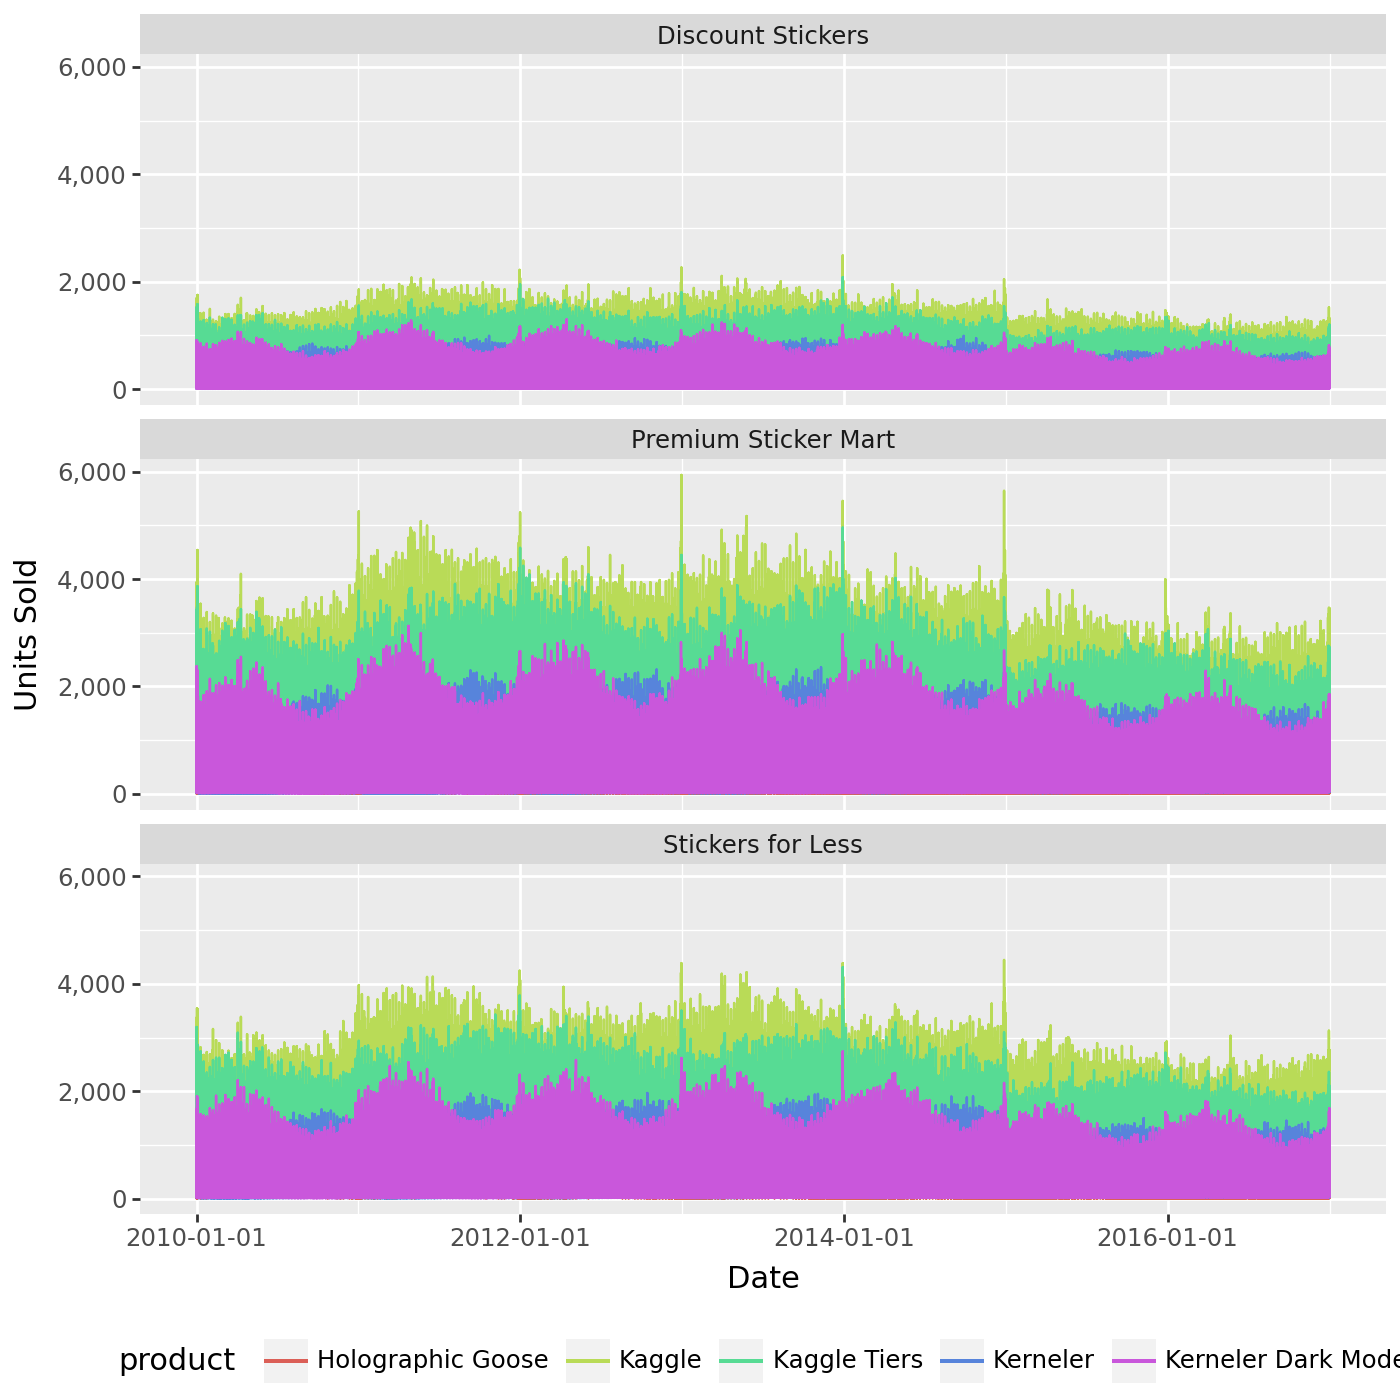

In [15]:
ggplot(train_df)\
    + geom_line(aes('date', 'num_sold', color='product'))\
    + facet_wrap('~store', ncol=1)\
    + theme(legend_position='bottom', figure_size=(7, 7))\
    + labs(x='Date', y='Units Sold')\
    + scale_y_continuous(labels=label_comma())

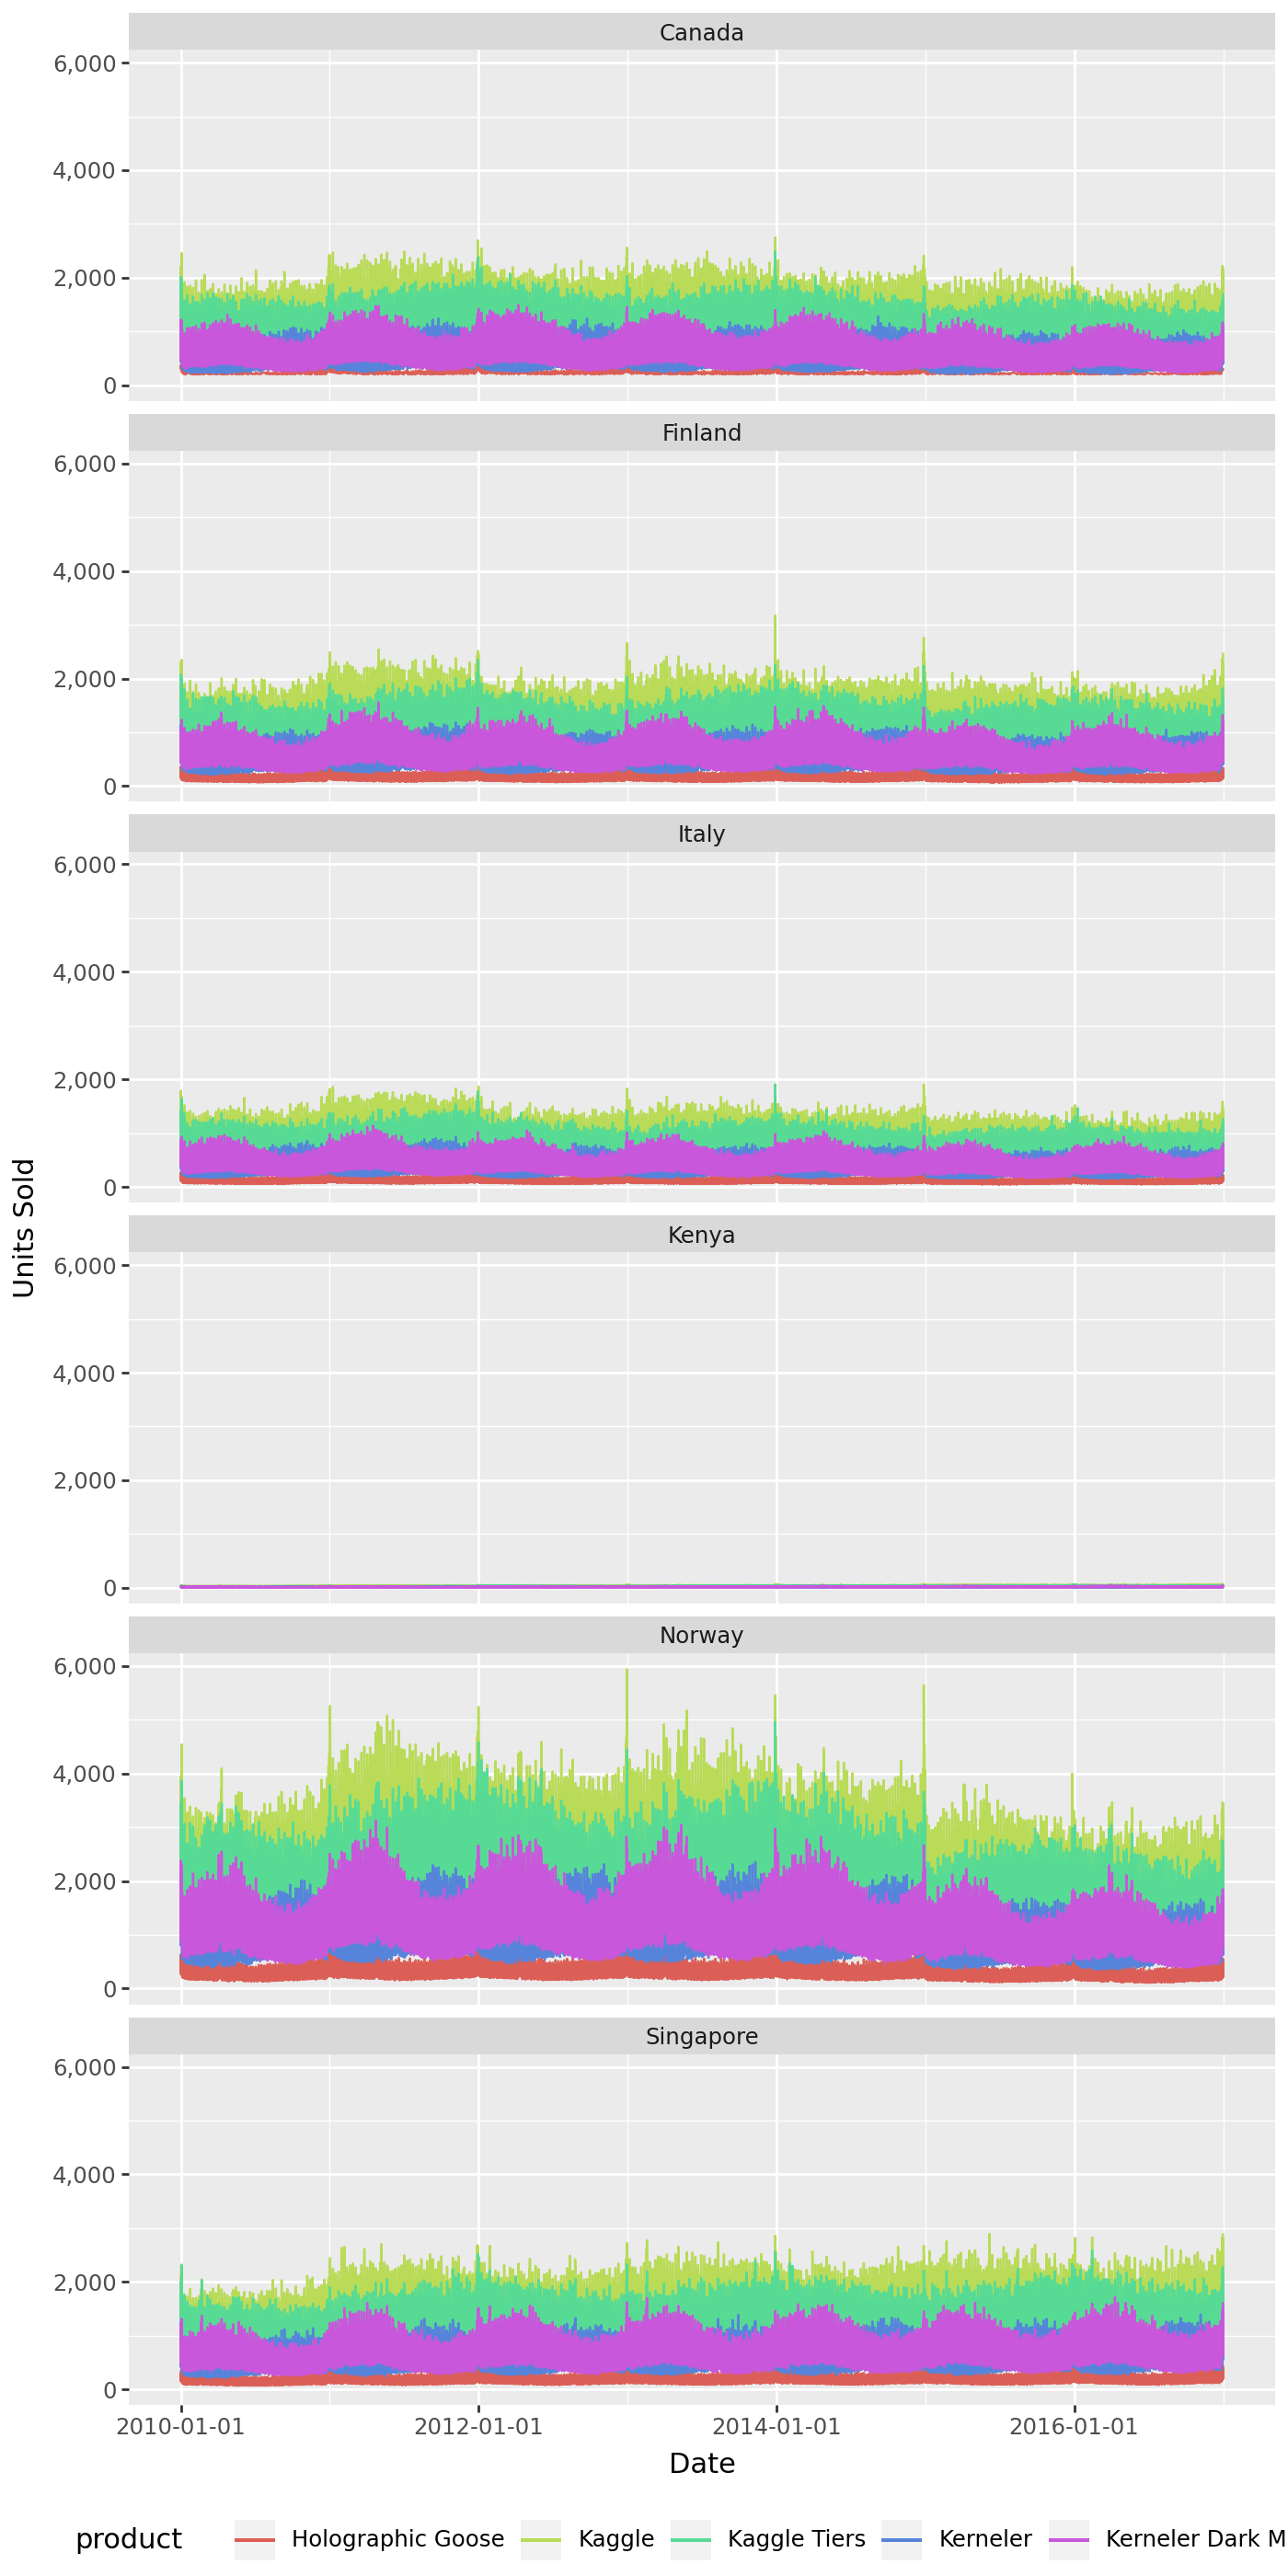

In [16]:
ggplot(train_df)\
    + geom_line(aes('date', 'num_sold', color='product'))\
    + facet_wrap('~country', ncol=1)\
    + theme(legend_position='bottom', figure_size=(7, 14))\
    + labs(x='Date', y='Units Sold')\
    + scale_y_continuous(labels=label_comma())

### Timeseries Autocorrelation and Partial Autocorrelation

Reference: 
* https://medium.com/@kis.andras.nandor/understanding-autocorrelation-and-partial-autocorrelation-functions-acf-and-pacf-2998e7e1bcb5
* https://statisticsbyjim.com/time-series/autocorrelation-partial-autocorrelation/
* https://medium.com/@sophiamsac/arima-vs-sarima-vs-sarimax-03dd04fc7c66
* https://analyticsindiamag.com/ai-trends/quick-way-to-find-p-d-and-q-values-for-arima/
  

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

In [18]:
# filter date and class variable
timeseries = train_df[['date', 'num_sold']].set_index('date')

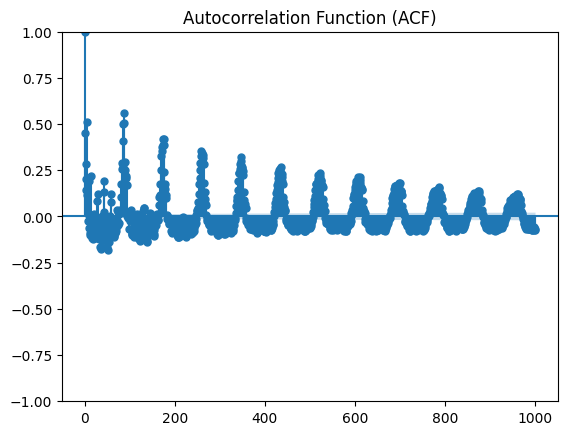

In [19]:
# plot autocorrelation function (ACF)
plot_acf(timeseries, lags=1000) 
plt.title('Autocorrelation Function (ACF)')
plt.show()

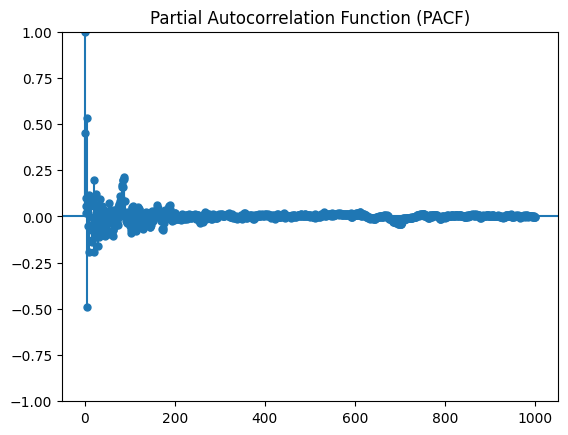

In [20]:
# plot partial autocorrelation function (PACF)
plot_pacf(timeseries, lags=1000, method='ywm')  # 'ywm' is often used for PACF
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

### Stationary Non-Stationary ADF Test

In [21]:
from statsmodels.tsa.stattools import adfuller

In [22]:
def adf_test(ts: pd.Series) -> pd.DataFrame: 
    
    output = adfuller(ts)
    column_names = ['T', 'p-val', 'no. of lags', 'no. of obs']
    results = {k: v for k, v in zip(column_names, output)}
    results_df = pd.DataFrame.from_dict(results, orient='index').T
    results_df['is_stationary'] = results_df['p-val'] < 0.05
    
    return results_df

In [23]:
adf_results_df = adf_test(timeseries)

In [24]:
adf_results_df

,T,p-val,no. of lags,no. of obs,is_stationary
0,-32.105705,0.0,83.0,221175.0,True


### Preparation

In [25]:
from feature_engine.datetime import DatetimeFeatures, DatetimeSubtraction
from feature_engine.creation import CyclicalFeatures
from sklearn.preprocessing import OneHotEncoder
import pandas_flavor as pf

In [26]:
@pd.api.extensions.register_dataframe_accessor("ts_pipe")
class TimeSeriesPipe:

    def __init__(self, df):
        self.df = df
        self.date_features = self.make_date_features(df)

    @staticmethod
    def make_date_features(df):
        
        dtf = DatetimeFeatures(features_to_extract=['year', 'month', 'day_of_month'])
        date_features = dtf.fit_transform(df['date'].to_frame())
        return date_features
        
    def extract_datetime_features(self) -> pd.DataFrame:         
        output_df = pd.concat([self.df, self.date_features], axis=1)
        
        return output_df
    
    def transform_timeseries_cyclical(self) -> pd.DataFrame:
        
        cyclical = CyclicalFeatures(variables=None, drop_original=True)
        X = cyclical.fit_transform(self.date_features)
        output_df = pd.concat([self.df, X], axis=1)\
            .drop(['date_year', 'date_month', 'date_day_of_month', 'index'], axis=1)\
            .set_index('date')
        
        return output_df


@pf.register_dataframe_method
def encode_features(df) -> pd.DataFrame:
    
    ohc = OneHotEncoder(sparse_output=False)
    num_features = df.select_dtypes('number')
    num_col_names = num_features.columns 
    
    obj_encoded_features = ohc.fit_transform(df.reset_index().select_dtypes('object'))
    encoded_df = pd.DataFrame(obj_encoded_features, columns=ohc.get_feature_names_out())
    output_df = pd.concat([df[num_col_names].reset_index(drop=True), encoded_df], axis=1)

    return output_df

In [27]:
X, y = train_df.get_features_targets('num_sold')

In [28]:
# preprocess data
X = X\
    .drop('id', axis=1)\
    .reset_index()\
    .ts_pipe.extract_datetime_features()\
    .ts_pipe.transform_timeseries_cyclical()\
    .encode_features()

In [29]:
X

,date_year_sin,date_year_cos,date_month_sin,date_month_cos,date_day_of_month_sin,date_day_of_month_cos,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,-1.869887e-02,0.999825,5.000000e-01,0.866025,2.012985e-01,0.97953,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-1.869887e-02,0.999825,5.000000e-01,0.866025,2.012985e-01,0.97953,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.869887e-02,0.999825,5.000000e-01,0.866025,2.012985e-01,0.97953,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.869887e-02,0.999825,5.000000e-01,0.866025,2.012985e-01,0.97953,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.869887e-02,0.999825,5.000000e-01,0.866025,2.012985e-01,0.97953,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221254,-2.449294e-16,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.00000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
221255,-2.449294e-16,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.00000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
221256,-2.449294e-16,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.00000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
221257,-2.449294e-16,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.00000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### SARIMA Baseline Model
*(Seasonal Autoregressive Integrated Moving Average)*

In [30]:
from statsmodels.tsa.arima.model import ARIMA

In [31]:
p, d, q = 1, 0, 1
mod = ARIMA(timeseries, order=(p, d, q))
mod_fit = mod.fit()
print(mod_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               num_sold   No. Observations:               221259
Model:                 ARIMA(1, 0, 1)   Log Likelihood            -1733500.840
Date:                Sat, 25 Jan 2025   AIC                        3467009.679
Time:                        08:16:36   BIC                        3467050.907
Sample:                             0   HQIC                       3467021.760
                             - 221259                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        752.5274      4.363    172.470      0.000     743.976     761.079
ar.L1          0.7456      0.003    293.467      0.000       0.741       0.751
ma.L1         -0.3966      0.003   -114.218      0.0

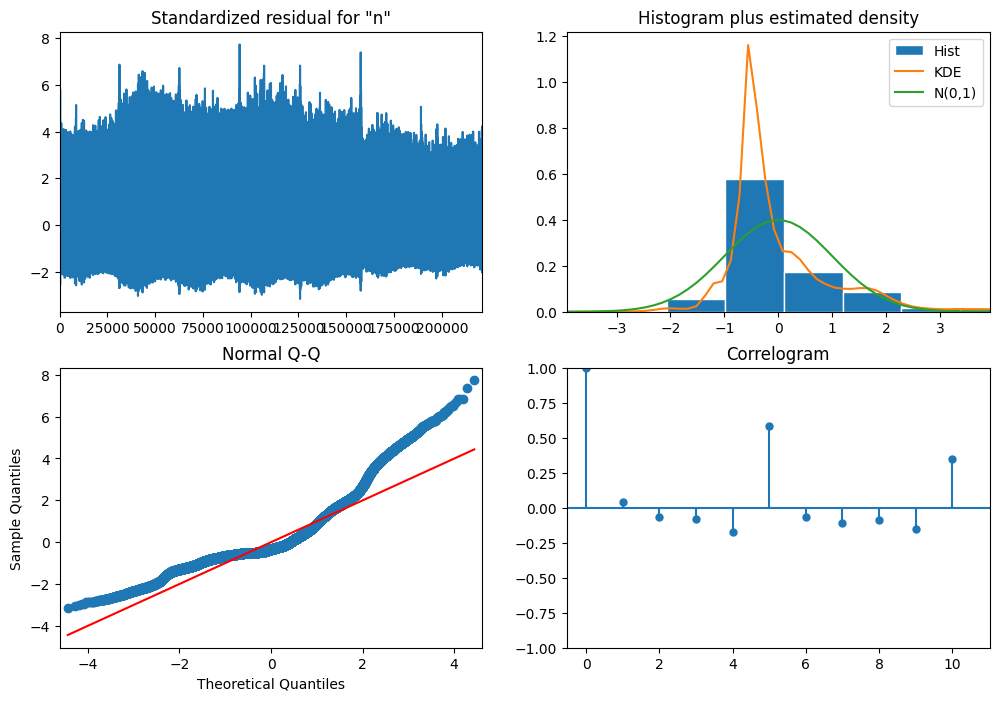

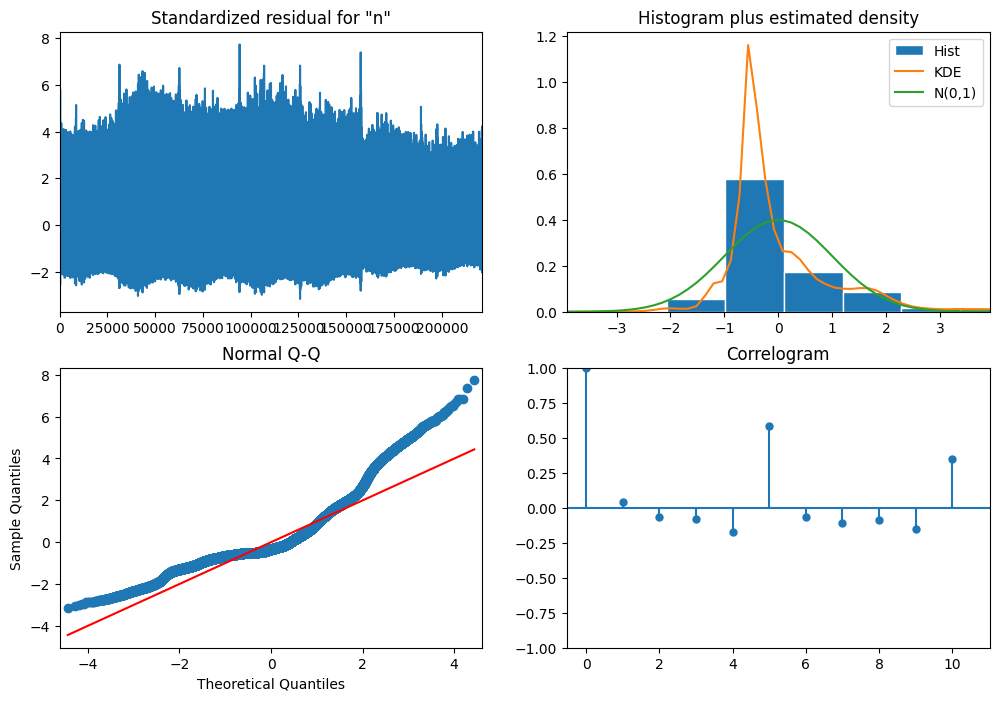

In [32]:
mod_fit.plot_diagnostics(figsize=(12, 8))

### Modeling

In [33]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from feature_engine.timeseries.forecasting import WindowFeatures, LagFeatures
import janitor.timeseries

In [34]:
def get_model_score(model, input_x, input_y):

    # split data
    X_train, X_test, y_train, y_test = train_test_split(
        input_x, input_y, train_size=.8, random_state=25)

    # model
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='mape')

    # predict
    y_pred = model.predict(X_test)

    # score
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    return mape

#### Base Model Scores (LGBM, XGB)

In [35]:
get_model_score(LGBMRegressor(), X, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 122
[LightGBM] [Info] Number of data points in the train set: 177007, number of used features: 20
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 752.570090


0.16375674870349213

In [36]:
get_model_score(XGBRegressor(), X, y)

[0]	validation_0-mape:6.33316
[1]	validation_0-mape:4.46351
[2]	validation_0-mape:3.15516
[3]	validation_0-mape:2.24278
[4]	validation_0-mape:1.59901
[5]	validation_0-mape:1.15012
[6]	validation_0-mape:0.84247
[7]	validation_0-mape:0.65508
[8]	validation_0-mape:0.48901
[9]	validation_0-mape:0.38300
[10]	validation_0-mape:0.31885
[11]	validation_0-mape:0.26917
[12]	validation_0-mape:0.25501
[13]	validation_0-mape:0.21777
[14]	validation_0-mape:0.22102
[15]	validation_0-mape:0.21317
[16]	validation_0-mape:0.22445
[17]	validation_0-mape:0.21404
[18]	validation_0-mape:0.22447
[19]	validation_0-mape:0.22267
[20]	validation_0-mape:0.21579
[21]	validation_0-mape:0.21924
[22]	validation_0-mape:0.22208
[23]	validation_0-mape:0.22468
[24]	validation_0-mape:0.22811
[25]	validation_0-mape:0.22937
[26]	validation_0-mape:0.23486
[27]	validation_0-mape:0.23863
[28]	validation_0-mape:0.22654
[29]	validation_0-mape:0.20654
[30]	validation_0-mape:0.20659
[31]	validation_0-mape:0.20531
[32]	validation_0-

0.2667853732541726

### Feature Engineering

In [37]:
train_wf = train_df\
    .sort_values(['date', 'country', 'store', 'product'])\
    .drop('id', axis=1)

unique_combination = train_wf[['country', 'store', 'product']].drop_duplicates()

In [38]:
def filter_timeseries(feature_model, df: pd.DataFrame, combinations: tuple) -> pd.DataFrame:
    c, s, p = combinations
    filtered_df = df[
        (df['country'] == c) & \
        (df['store'] == s) & \
        (df['product'] == p)]
    output_dataframe = feature_model.fit_transform(filtered_df)
    return output_dataframe

In [39]:
window_features_df = pd.concat([filter_timeseries(
    feature_model=WindowFeatures(window=2),
    df=train_wf, 
    combinations=unique_combination.iloc[i]
    ) for i in range(unique_combination.shape[0])]
) 

In [42]:
train_new_feat = janitor.timeseries.sort_timestamps_monotonically(window_features_df, direction='increasing')
train_new_feat_processed = window_features_df\
    .reset_index()\
    .ts_pipe.extract_datetime_features()\
    .ts_pipe.transform_timeseries_cyclical()\
    .encode_features()

In [43]:
X_fe, y_fe = train_new_feat_processed.get_features_targets('num_sold')

#### Feature Engineered Scores (LGBM, XGB)

In [44]:
get_model_score(LGBMRegressor(), X_fe, y_fe)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 377
[LightGBM] [Info] Number of data points in the train set: 177007, number of used features: 21
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 752.345941


0.12225933254630753

In [45]:
get_model_score(XGBRegressor(), X_fe, y_fe)

[0]	validation_0-mape:6.28390
[1]	validation_0-mape:4.41124
[2]	validation_0-mape:3.09923
[3]	validation_0-mape:2.18514
[4]	validation_0-mape:1.54647
[5]	validation_0-mape:1.10204
[6]	validation_0-mape:0.79217
[7]	validation_0-mape:0.57689
[8]	validation_0-mape:0.42610
[9]	validation_0-mape:0.32185
[10]	validation_0-mape:0.24950
[11]	validation_0-mape:0.19931
[12]	validation_0-mape:0.16488
[13]	validation_0-mape:0.14160
[14]	validation_0-mape:0.12600
[15]	validation_0-mape:0.12039
[16]	validation_0-mape:0.11362
[17]	validation_0-mape:0.10894
[18]	validation_0-mape:0.10651
[19]	validation_0-mape:0.10578
[20]	validation_0-mape:0.10641
[21]	validation_0-mape:0.10757
[22]	validation_0-mape:0.10707
[23]	validation_0-mape:0.10786
[24]	validation_0-mape:0.10742
[25]	validation_0-mape:0.10618
[26]	validation_0-mape:0.10582
[27]	validation_0-mape:0.10437
[28]	validation_0-mape:0.10464
[29]	validation_0-mape:0.10458
[30]	validation_0-mape:0.10647
[31]	validation_0-mape:0.10774
[32]	validation_0-

0.11712414098382638

### Hyperparameter Optimization

In [46]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [47]:
train_new_feat_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221259 entries, 0 to 221258
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   num_sold                    221259 non-null  float64
 1   num_sold_window_2_mean      221083 non-null  float64
 2   date_year_sin               221259 non-null  float64
 3   date_year_cos               221259 non-null  float64
 4   date_month_sin              221259 non-null  float64
 5   date_month_cos              221259 non-null  float64
 6   date_day_of_month_sin       221259 non-null  float64
 7   date_day_of_month_cos       221259 non-null  float64
 8   country_Canada              221259 non-null  float64
 9   country_Finland             221259 non-null  float64
 10  country_Italy               221259 non-null  float64
 11  country_Kenya               221259 non-null  float64
 12  country_Norway              221259 non-null  float64
 13  country_Singap

In [48]:
from hyperopt.pyll.base import scope

In [49]:
space = {'max_depth': scope.int(hp.quniform("max_depth", 1, 5, 1)),
        'gamma': hp.uniform ('gamma', 0,1),
        'reg_alpha' : hp.uniform('reg_alpha', 0,50),
        'reg_lambda' : hp.uniform('reg_lambda', 10,100),
        'colsample_bytree' : hp.uniform('colsample_bytree', 0,1),
        'min_child_weight' : hp.uniform('min_child_weight', 0, 5),
        'n_estimators': 10000,
        'learning_rate': hp.uniform('learning_rate', 0, .15),
        'tree_method':'gpu_hist', 
        'gpu_id': 0,
        'random_state': 5,
        'max_bin' : scope.int(hp.quniform('max_bin', 200, 550, 1))}

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_fe, y_fe, train_size=.8, random_state=25)

In [54]:
def hyperparameter_tuning(space):
    model = XGBRegressor(**space)
    evaluation = [(X_train, y_train), (X_test, y_test)]
    
    model.fit(X_train, y_train,
            eval_set=evaluation, eval_metric="rmse",
            early_stopping_rounds=100,verbose=False)

    pred = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, pred)
    print ("SCORE:", mape)
    return {'loss':mape, 'status': STATUS_OK, 'model': model}

In [55]:
trials = Trials()
best = fmin(fn=hyperparameter_tuning,
            space=space,
            algo=tpe.suggest,
            max_evals=30,
            trials=trials)

print(best)

SCORE:                                                
0.1450533313844557                                    
SCORE:                                                                          
0.25049212275492966                                                             
SCORE:                                                                          
0.2351605998127138                                                              
SCORE:                                                                          
0.15081493250191091                                                             
SCORE:                                                                          
0.156240697125652                                                               
SCORE:                                                                          
0.491120336857796                                                               
SCORE:                                                                          